In [41]:
from qick import *
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\IPython\core\magics\pylab.py:162: UserWarning: pylab import has clobbered these variables: ['f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [42]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import xarray as xr

In [43]:
import os
import sys
sys.path.insert(0, '../../pattern/')
sys.path.insert(0, '../../instrument/')

In [44]:
from xilinx_qick.class_drx import drx
from xilinx_qick.class_rox import rox
from xilinx_qick.class_sweep import sweep
from xilinx_qick.instr_xilinx_v1 import XilinxProg

In [65]:
xilinx_1 = XilinxProg(ip_address="10.0.100.21", mode='AveragerProgram')
xilinx_1.reps = 100

dr_ch1 = 0
ro_ch1 = 0



Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
rfsoc4x2_1 PYRO:obj_6aec762e7d7e4127ba232b014f3e4391@10.0.100.21:44885
QICK running on RFSoC4x2, software version 0.2.381

Firmware configuration (built Wed Sep  6 18:49:29 2023):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0], [DAC tile 2], [ADC tile 0]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.0 (no edge counter, no weights)
		memory 16384 accumulated, 1024 decima

In [73]:
freq_list = np.arange(152, 158, 0.3) * 1e6

In [90]:
#freq_list = np.arange(150, 159, 0.2) * 1e6

# plt.figure()
# plt.show()
for freq_idx, freq_ch1 in enumerate(freq_list):
    dr_readout = drx(soc=xilinx_1.soccfg,
                     dr_ch=0, ro_ch=0,
                     frequency= freq_ch1 / 1e6, gain=0.7,
                     phase=0, delay=0.2, sleep=1)

    s_0 = np.array([0, 1, 1, 1, 0])
    ph_0 = 0.89974298+0.43642018j


    dr_readout.wave.add(name='x2', t_data=[0, 0.25, 0.5, 1.25, 1.5], s_data=s_0/ph_0, idx=-1, interp_order=3)
    dr_readout.rox.set(frequency=freq_ch1 / 1e6, length=1.5, delay=0.2, sleep=1)
    xilinx_1.add(dr_readout=dr_readout)


    # dr_heat = drx(soc=xilinx_1.soccfg,
    #                  dr_ch=1, ro_ch=1,
    #                  frequency= 7.77e9 / 1e6, gain=1,
    #                  phase=0, delay=0.2, sleep=1)

    s_1 = np.array([0, 1, 1, 1, 0])
    ph_1 = 0.89974298+0.43642018j

    # dr_heat.wave.add(name='x2', t_data=[0, 0.25, 0.5, 1.25, 1.5], s_data=s_1/ph_1, idx=-1, interp_order=3)
    # #dr_heat.rox.set(frequency=freq_ch1 / 1e6, length=1, delay=0.2, sleep=1)
    # xilinx_1.add(dr_heat=dr_heat)

    #iq_data = xilinx_1.acquire_decimated(load_pulses=True, progress=False)
    iq_data = xilinx_1.acquire(load_pulses=True, progress=False)

    file_name= 'test_' + str(freq_idx) + '.zarr'
    iq_data.to_zarr(file_name, mode='w')

    #plt.plot(freq_idx, np.max(np.abs(iq_data)),'.-')


C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\zarr\api\asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


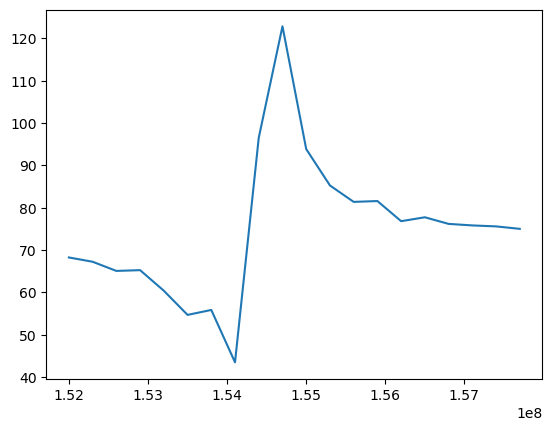

In [83]:
iq_idx = []


for freq_idx, freq_ch1 in enumerate(freq_list):
    file_name= 'test_' + str(freq_idx) + '.zarr'
    with xr.open_zarr(file_name) as f:
        iq_mat = f['IQ accumulated']

    iq_idx.append(iq_mat.sel(rox=0).data)




iq_idx = np.array(iq_idx)

plt.figure()
#plt.plot(np.max(np.abs(iq_mat)),'.-')
plt.plot(freq_list, np.mean(np.abs(iq_idx), axis=1))

#plt.plot(freq_list, np.mean(np.imag(iq_idx), axis=1))
#plt.plot(freq_list, np.mean(np.real(iq_idx), axis=1))
#plt.plot(np.mean(np.real(iq_idx), axis=1),np.mean(np.imag(iq_idx), axis=1))
# plt.plot(iq_mat.ticks, np.mean(np.abs(iq_idx), axis=1))
plt.show()



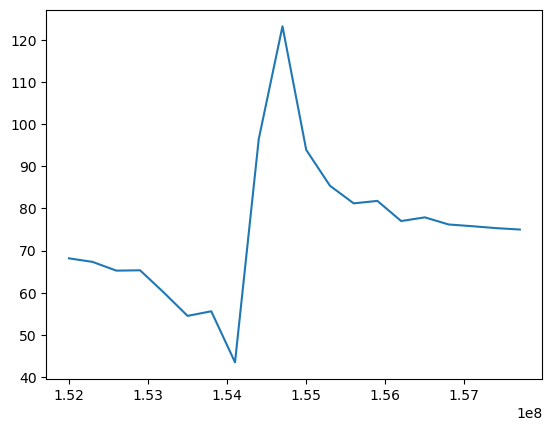

In [91]:
iq_idx = []
for freq_idx, freq_ch1 in enumerate(freq_list):
    file_name= 'test_' + str(freq_idx) + '.zarr'
    with xr.open_zarr(file_name) as f:
        iq_mat = f['IQ accumulated']

    iq_idx.append(iq_mat.sel(rox=0).data)

iq_idx = np.array(iq_idx)

plt.figure()
plt.plot(freq_list, np.mean(np.abs(iq_idx), axis=1))
plt.show()


In [12]:
iq_idx = []
for freq_idx, freq_ch1 in enumerate(freq_list):
    file_name= 'test_' + str(freq_idx) + '.zarr'
    with xr.open_zarr(file_name) as f:
        iq_mat = f['IQ decimated']

    iq_idx.append(iq_mat.sel(rox=0).data)

iq_idx = np.array(iq_idx)

plt.figure()
#plt.plot(freq_list, np.mean(np.abs(iq_idx), axis=1))
plt.plot(freq_list, np.mean(np.imag(iq_idx), axis=1))
plt.plot(freq_list, np.mean(np.real(iq_idx), axis=1))
#plt.plot(np.mean(np.real(iq_idx), axis=1),np.mean(np.imag(iq_idx), axis=1))
plt.show()


Traceback (most recent call last):
  File "C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\xarray\core\dataset.py", line 1231, in _construct_dataarray
    variable = self._variables[name]
               ~~~~~~~~~~~~~~~^^^^^^
KeyError: 'IQ decimated'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\xarray\core\dataset.py", line 1338, in __getitem__
    return self._construct_dataarray(key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\xarray\core\dataset.py", line 1233, in _construct_dataarray
    _, name, variable = _get_virtual_variable(self._variables, name, self.sizes)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\xarray\core\dataset_utils.py", line 79, in _get_virtual_variable
    raise KeyEr

In [12]:
#freq_ch1 = 540e6
freq_ch1 = 155e6

dr_readout = drx(soc=xilinx_1.soccfg,
                 dr_ch=dr_ch1, ro_ch=ro_ch1,
                 frequency= freq_ch1 / 1e6, gain=1,
                 phase=0, delay=0.2, sleep=1)

s_1 = np.array([0, 1, 2, 1, 0])
ph_1=1
# ph_1 = 0.89974298+0.43642018j

dr_readout.wave.add(name='x2', t_data=[0, 0.25, 0.5, 0.75, 1.0], s_data=s_1/ph_1, idx=-1, interp_order=3)
dr_readout.rox.set(frequency=freq_ch1 / 1e6, length=1, delay=0.2, sleep=1)
xilinx_1.add(dr_readout=dr_readout)


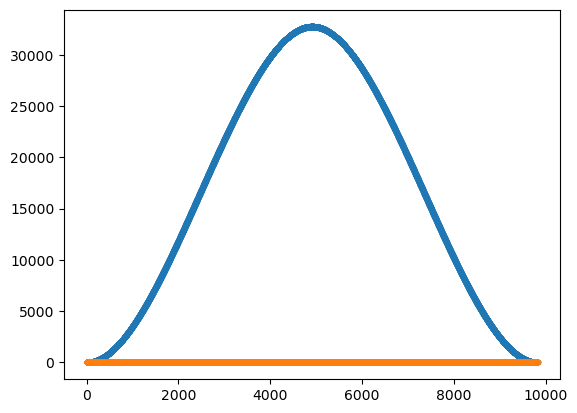

In [13]:
plt.figure()
plt.plot(dr_readout.wave.items[0].i_data, '.-')
plt.plot(dr_readout.wave.items[0].q_data, '.-')
plt.show()

In [14]:
iq_data = xilinx_1.acquire_decimated(load_pulses=True, progress=False)
iq_data.to_zarr('test_1.zarr', mode='w')

Traceback (most recent call last):
  File "C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\qcduser\AppData\Local\Temp\ipykernel_27556\2391161462.py", line 1, in <module>
    iq_data = xilinx_1.acquire_decimated(load_pulses=True, progress=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\qcduser\GitProjects\QCDLabs\lab\260618_shiling\../../instrument\xilinx_qick\instr_xilinx_v1.py", line 80, in acquire_decimated
    return self._prog_cache.acquire_decimated(self.soc, load_pulses=load_pulses, progress=progress)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\qcduser\GitProjects\QCDLabs\instrument\xilinx_qick\class_AveProg.py", line 106, in acquire_decimated
    iq_list = super().acquire_decimated(soc, progress=progress)
              ^

In [1]:
with xr.open_zarr("test_1.zarr") as f:
    iq_mat = f['IQ decimated']

NameError: name 'xr' is not defined

In [2]:
plt.figure()
plt.plot(iq_mat.ticks, np.real(iq_mat.sel(rox=0)), '.-')
plt.plot(iq_mat.ticks, np.imag(iq_mat.sel(rox=0)), '.-')
plt.show()

NameError: name 'plt' is not defined

In [3]:
x=np.max(np.real(iq_mat.sel(rox=0))).compute() + 1j*np.max(np.imag(iq_mat.sel(rox=0))).compute()
ph = x/np.abs(x)
print(ph)

NameError: name 'np' is not defined